# FIFA Veri Seti ile Uygulamalı İstatistik Analizi
Ben ve gemini arkadaşım bu çalışmada bir futbolcu veri seti üzerinden temel istatistiksel adımları uyguluyoruz (inanılmaz sıkışık bir döneme denk geldi task o yüzden AI'a bıraktım bu taskı Mehmet Hocam):
1. Veri temizleyecez
2. Betimsel istatistikler ve normallik testleri
3. İki ve çoklu grup karşılaştırmaları
4. Kategorik analiz
5. Çoklu regresyon ve PCA

In [4]:
# 1. Gerekli kütüphanelerin yüklenmesi
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Adım 1: Veriyi Yükleme ve İlk Temizlik
- CSV dosyasını okuyoruz.
- Varsa tekrar eden satırları temizliyoruz.
- Hangi sütunda ne kadar eksik veri var hızlıca özetliyoruz.

In [5]:
df = pd.read_csv('fifa_eda.csv')
print(f"Orijinal Satır/Sütun Boyutu: {df.shape}")

# Mükerrer satır kontrolü
tekrar_eden = df.duplicated().sum()
print(f"Tekrar eden satır sayısı: {tekrar_eden}")
if tekrar_eden > 0:
    df.drop_duplicates(inplace=True)

# Eksik değerler ve sütun tipleri tablosu
ozet_tablosu = pd.DataFrame({
    "Veri Tipi": df.dtypes,
    "Benzersiz Deger": df.nunique(),
    "Eksik Sayisi": df.isnull().sum(),
    "Eksik Orani (%)": (df.isnull().mean() * 100).round(2)
})
display(ozet_tablosu)

# Analizde sık kullanacağımız sütunlar
sayisal_sutunlar = ['Age', 'Overall', 'Potential', 'Value', 'Wage']
kategorik_sutunlar = ['Preferred Foot', 'International Reputation']

df[sayisal_sutunlar].head()

Orijinal Satır/Sütun Boyutu: (18207, 18)
Tekrar eden satır sayısı: 0


,Veri Tipi,Benzersiz Deger,Eksik Sayisi,Eksik Orani (%)
ID,int64,18207,0,0.00
Name,object,17194,0,0.00
Age,int64,29,0,0.00
Nationality,object,164,0,0.00
Overall,int64,48,0,0.00
Potential,int64,47,0,0.00
Club,object,651,241,1.32
Value,float64,216,252,1.38
Wage,float64,144,0,0.00
Preferred Foot,object,2,0,0.00


,Age,Overall,Potential,Value,Wage
0,31,94,94,110500.0,565.0
1,33,94,94,77000.0,405.0
2,26,92,93,118500.0,290.0
3,27,91,93,72000.0,260.0
4,27,91,92,102000.0,355.0


### Adım 2: Betimsel İstatistikler ve %95 Güven Aralığı
- **Güven Aralığı:** Anakütle ortalamasının %95 olasılıkla hangi alt-üst sınır arasında kaldığını gösterir.
- **Skew (Çarpıklık):** Dağılımın simetrik olup olmadığıdır. 0'dan çok büyükse (örn: Value ve Wage) veri sağa çarpıktır (az sayıda kişi devasa kazanıyor demektir).
- **Kurtosis (Basıklık):** Uç değerlerin/kuyrukların ne kadar sivri olduğunu belirtir.

In [6]:
# %95 Güven Aralığı hesaplama fonksiyonu
def guven_araligi_hesapla(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ort = veri.mean()
    standart_hata = stats.sem(veri)
    t_degeri = stats.t.ppf((1 + guven) / 2, df=n - 1)
    hata_payi = t_degeri * standart_hata
    return ort, ort - hata_payi, ort + hata_payi

print(f"{'Değişken':20s} {'Ortalama':>12s} {'%95 Alt Sınır':>14s} {'%95 Üst Sınır':>14s}")
print("-" * 65)
for col in sayisal_sutunlar:
    ort, alt, ust = guven_araligi_hesapla(df[col])
    print(f"{col:20s} {ort:>12.2f} {alt:>14.2f} {ust:>14.2f}")

# Özet istatistik tablosu (çarpıklık ve basıklık eklenmiş)
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew (çarpıklık)"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis (basıklık)"] = df[sayisal_sutunlar].kurtosis()
display(betimsel.round(2))

Değişken                 Ortalama  %95 Alt Sınır  %95 Üst Sınır
-----------------------------------------------------------------
Age                         25.12          25.05          25.19
Overall                     66.24          66.14          66.34
Potential                   71.31          71.22          71.40
Value                     2444.53        2362.22        2526.84
Wage                         9.73           9.41          10.05


,count,mean,std,min,25%,50%,75%,max,skew (çarpıklık),kurtosis (basıklık)
Age,18207.0,25.12,4.67,16.0,21.0,25.0,28.0,45.0,0.39,-0.46
Overall,18207.0,66.24,6.91,46.0,62.0,66.0,71.0,94.0,0.07,0.10
Potential,18207.0,71.31,6.14,48.0,67.0,71.0,75.0,95.0,0.27,0.04
Value,17955.0,2444.53,5626.72,10.0,325.0,700.0,2100.0,118500.0,7.03,76.00
Wage,18207.0,9.73,22.00,0.0,1.0,3.0,9.0,565.0,7.91,100.71


### Adım 3: Normallik Testleri ve Q-Q Grafikleri
Verinin çan eğrisi (normal dağılım) kuralına uyup uymadığını kontrol ediyoruz:
- **H0:** Veri normal dağılır.
- **H1:** Veri normal dağılmaz.
- **Kural:** `p < 0.05` ise H0 reddedilir; yani veri normal dağılmaz (non-parametrik testler tercih edilmelidir).
- **Q-Q Grafiği:** Noktalar kırmızı çizgi üzerinde diziliyorsa veri normaldir, çizgiden fırlıyorsa normallikten uzaktır.

Değişken          Shapiro p-değeri Karar
-------------------------------------------------------
Age                         0.0000   Normal Dağılmıyor
Overall                     0.0000   Normal Dağılmıyor
Potential                   0.0000   Normal Dağılmıyor
Value                       0.0000   Normal Dağılmıyor
Wage                        0.0000   Normal Dağılmıyor


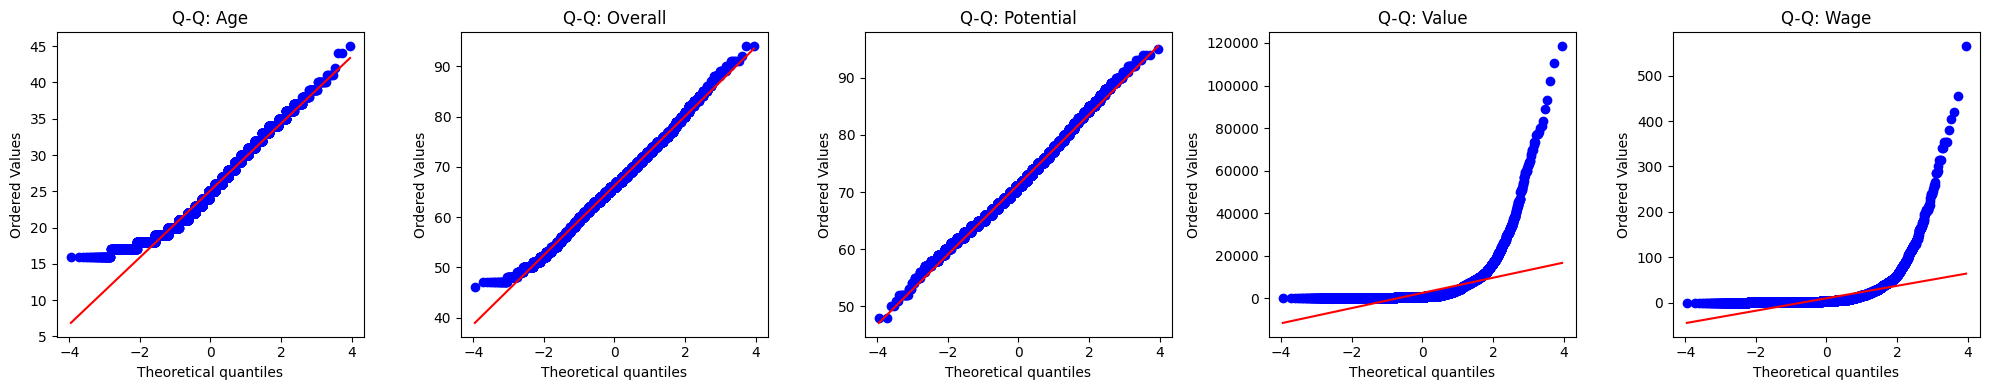

In [7]:
print(f"{'Değişken':15s} {'Shapiro p-değeri':>18s} {'Karar'}")
print("-" * 55)
for col in sayisal_sutunlar:
    veri = df[col].dropna()
    # Shapiro-Wilk büyük verilerde hassas olduğu için rastgele 5000 örnek seçiyoruz
    ornek = veri.sample(min(len(veri), 5000), random_state=42)
    _, p_degeri = stats.shapiro(ornek)
    
    durum = "Normal Dağılıyor" if p_degeri > 0.05 else "Normal Dağılmıyor"
    print(f"{col:15s} {p_degeri:>18.4f}   {durum}")

# Q-Q Grafikleri ile görselleştirme
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(20, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q: {col}")
plt.tight_layout()
plt.show()

### Adım 4: İki Bağımsız Grup Karşılaştırması
**Soru:** Sol ayaklı futbolcular ile sağ ayaklı futbolcuların yetenekleri (Overall) arasında fark var mı?
1. **Levene Testi:** Grupların varyansları eşit mi? (`p < 0.05` ise varyanslar eşit değil).
2. **Hipotez Testi Seçimi:** Normallik şartı sağlanmadığı için **Mann-Whitney U** (non-parametrik test) kullanılır.

In [8]:
sol_ayak = df.loc[df["Preferred Foot"] == "Left", "Overall"].dropna()
sag_ayak = df.loc[df["Preferred Foot"] == "Right", "Overall"].dropna()

# 1. Varyans homojenliği kontrolü
_, p_levene = stats.levene(sol_ayak, sag_ayak)
print(f"Levene p-değeri: {p_levene:.4f} -> Varyanslar {'homojen' if p_levene > 0.05 else 'homojen değil'}")

# 2. Test seçimi ve uygulama
# Normallik bozulduğu için Mann-Whitney U testi yapıyoruz
u_istatistigi, p_test = stats.mannwhitneyu(sol_ayak, sag_ayak, alternative='two-sided')
print(f"Mann-Whitney U Testi p-değeri: {p_test:.4f}")

if p_test < 0.05:
    print("Karar: Ayak tercihi ile Overall puanı arasında istatistiksel olarak ANLAMLI bir fark VAR.")
else:
    print("Karar: Gruplar arasında anlamlı bir fark YOK.")

Levene p-değeri: 0.0000 -> Varyanslar homojen değil
Mann-Whitney U Testi p-değeri: 0.0000
Karar: Ayak tercihi ile Overall puanı arasında istatistiksel olarak ANLAMLI bir fark VAR.


### Adım 5: Çoklu Grup Karşılaştırması (ANOVA ve Kruskal-Wallis)
**Soru:** Uluslararası İtibar (Reputation: 1, 2, 3, 4, 5) arttıkça Overall değişiyor mu?
- İkiden fazla grup olduğu için **ANOVA** veya non-parametrik karşılığı **Kruskal-Wallis** kullanılır.
- **Eta-Kare (η²):** Farkın etki büyüklüğüdür (ne kadar güçlü olduğunu söyler).
- **Tukey HSD (Post-Hoc):** Fark varsa, bu farkın *hangi iki grup arasından* kaynaklandığını gösterir.

In [9]:
# Yeterli oyuncu sayısına sahip itibar grupları
gruplar = [grup["Overall"].dropna().values for _, grup in df.groupby("International Reputation") if len(grup) >= 30]

# Testler
f_stat, p_anova = stats.f_oneway(*gruplar)
h_stat, p_kw = stats.kruskal(*gruplar)

print(f"ANOVA p-değeri: {p_anova:.4e}")
print(f"Kruskal-Wallis p-değeri: {p_kw:.4e}")

# Etki büyüklüğü (Eta-Kare)
genel_ort = df["Overall"].mean()
gruplar_arasi_kareler = sum(len(g) * (g.mean() - genel_ort)**2 for g in gruplar)
toplam_kareler = sum((df["Overall"].dropna() - genel_ort)**2)
eta_kare = gruplar_arasi_kareler / toplam_kareler
print(f"Eta-Kare (η²): {eta_kare:.4f} (0.14 üzeri büyük etki demektir)")

# Hangi gruplar farklı? (Tukey HSD)
if p_anova < 0.05:
    print("\n--- Gruplar Arası Karşılaştırma (Tukey HSD) ---")
    alt_veri = df.dropna(subset=["Overall", "International Reputation"])
    tukey_sonucu = pairwise_tukeyhsd(endog=alt_veri["Overall"], groups=alt_veri["International Reputation"], alpha=0.05)
    print(tukey_sonucu)

ANOVA p-değeri: 0.0000e+00
Kruskal-Wallis p-değeri: 0.0000e+00
Eta-Kare (η²): 0.2517 (0.14 üzeri büyük etki demektir)

--- Gruplar Arası Karşılaştırma (Tukey HSD) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   1.0    2.0  10.3768    0.0  9.9014 10.8522   True
   1.0    3.0  16.1463    0.0  15.212 17.0806   True
   1.0    4.0  21.0287    0.0 18.7467 23.3106   True
   1.0    5.0  25.6463    0.0 19.0023 32.2904   True
   2.0    3.0   5.7695    0.0  4.7366  6.8024   True
   2.0    4.0  10.6518    0.0  8.3278 12.9759   True
   2.0    5.0  15.2695    0.0  8.6109 21.9281   True
   3.0    4.0   4.8824    0.0   2.423  7.3417   True
   3.0    5.0      9.5 0.0011   2.793  16.207   True
   4.0    5.0   4.6176 0.3772 -2.4051 11.6404  False
----------------------------------------------------


### Adım 6: Kategorik Değişken İlişkisi (Ki-Kare ve Cramér's V)
İki kategorik sütun (Ayak Tercihi vs. Uluslararası İtibar) arasında bağlantı var mı?
- **Ki-Kare Testi:** Bağımsızlık testi yapar (`p > 0.05` ise bu iki özellik birbirinden bağımsızdır).
- **Cramér's V:** İlişkinin kuvvetini ölçer (0'a yakınsa ilişki neredeyse yoktur).

In [10]:
# Cramér's V ilişki katsayısı hesabı
def cramers_v_hesapla(x, y):
    tablo = pd.crosstab(x, y)
    ki_kare = stats.chi2_contingency(tablo)[0]
    toplam_gozlem = tablo.sum().sum()
    min_boyut = min(tablo.shape) - 1
    return np.sqrt(ki_kare / (toplam_gozlem * min_boyut))

capraz_tablo = pd.crosstab(df["Preferred Foot"], df["International Reputation"])
ki2, p_degeri, serbestlik_derecesi, _ = stats.chi2_contingency(capraz_tablo)
v_katsayisi = cramers_v_hesapla(df["Preferred Foot"].dropna(), df["International Reputation"].dropna())

print(f"Ki-Kare: {ki2:.4f}, p-değeri: {p_degeri:.4f}")
print(f"Cramér's V: {v_katsayisi:.4f} (İlişki yok denecek kadar zayıf)")
display(capraz_tablo)

Ki-Kare: 1.8687, p-değeri: 0.7599
Cramér's V: 0.0101 (İlişki yok denecek kadar zayıf)


International Reputation,1.0,2.0,3.0,4.0,5.0
Preferred Foot,,,,,
Left,3839,290,66,15,1
Right,12693,971,243,36,5


### Adım 7: Korelasyon Isı Haritası (Heatmap)
Sayısal sütunların birbirleriyle doğrusal ilişkisine bakıyoruz. 1'e yakın değerler güçlü pozitif, -1 güçlü negatif ilişkiyi gösterir.

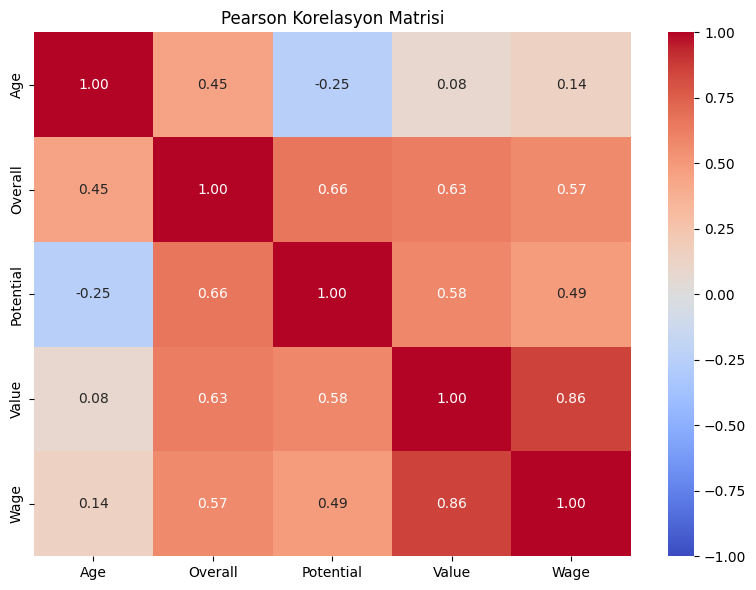

In [11]:
korelasyon = df[sayisal_sutunlar].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson Korelasyon Matrisi")
plt.tight_layout()
plt.show()

### Adım 8: Çoklu Bağlantı Kontrolü (VIF)
Regresyona sokacağımız bağımsız değişkenler birbirini aşırı derecede tekrar ediyor mu?
- **VIF < 5:** Temiz, bağımsız değişkenler arasında sorun yok demektir.
- **VIF > 10:** Çoklu doğrusal bağlantı (multicollinearity) problemi vardır, değişkenlerden biri elenmelidir.

In [12]:
X = df[['Age', 'Potential', 'Value']].dropna()
X_sabit = sm.add_constant(X)

vif_sonuc = pd.DataFrame({
    "Değişken": X.columns,
    "VIF Değeri": [VIF(X_sabit.values, i) for i in range(1, X_sabit.shape[1])]
})
print(vif_sonuc)

    Değişken  VIF Değeri
0        Age    1.161545
1  Potential    1.738442
2      Value    1.638327


### Adım 9: Çoklu Doğrusal Regresyon (OLS)
Bir oyuncunun **Overall** puanını; Yaş, Potansiyel, Bonservis Değeri ve Maaşıyla tahmin etmeye çalışıyoruz.
- Bonservis (`Value`) ve Maaş (`Wage`) aşırı sağa çarpık olduğu için `np.log1p` ile logaritmik dönüşüm uyguluyoruz.
- **R-squared:** Modelin bağımlı değişkendeki varyansı açıklama gücüdür (0.97 çok yüksek bir başarıdır).

In [13]:
reg_df = df[['Overall', 'Age', 'Potential', 'Value', 'Wage']].dropna().copy()

# Finansal değerlere logaritmik dönüşüm
reg_df['log_Value'] = np.log1p(reg_df['Value'])
reg_df['log_Wage'] = np.log1p(reg_df['Wage'])

# Regresyon modeli
reg_model = smf.ols(formula="Overall ~ Age + Potential + log_Value + log_Wage", data=reg_df).fit()
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Overall   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.976
Method:                 Least Squares   F-statistic:                 1.859e+05
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:42:43   Log-Likelihood:                -26568.
No. Observations:               17955   AIC:                         5.315e+04
Df Residuals:                   17950   BIC:                         5.319e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.0417      0.181     82.931      0.0

### Adım 10: Temel Bileşenler Analizi (PCA)
Boyut indirgeme tekniğidir. Sayısal değişkenlerin taşıdığı bilgiyi özetleyerek daha az sayıda yapay bileşene (PC1, PC2...) sıkıştırır.
- İlk adımda değişkenler mutlaka **StandardScaler** ile standartlaştırılır (ölçek farkını yok etmek için).

PC1: %58.62 (Kümülatif Toplam: %58.62)
PC2: %24.92 (Kümülatif Toplam: %83.54)
PC3: %12.48 (Kümülatif Toplam: %96.02)
PC4: %2.70 (Kümülatif Toplam: %98.72)
PC5: %1.28 (Kümülatif Toplam: %100.00)


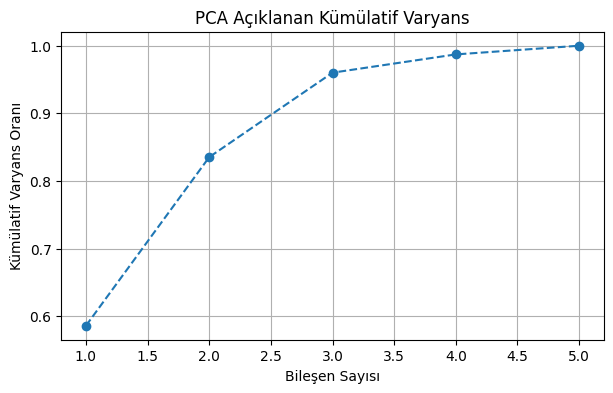

In [14]:
pca_veri = df[sayisal_sutunlar].dropna()

# 1. Standartlaştırma (Z-score)
olcekleyici = StandardScaler()
veri_standart = olcekleyici.fit_transform(pca_veri)

# 2. PCA Uygulama
pca = PCA()
pca.fit(veri_standart)

# Açıklanan varyans oranları
varyans_oranlari = pca.explained_variance_ratio_
for i, oran in enumerate(varyans_oranlari, 1):
    print(f"PC{i}: %{oran*100:.2f} (Kümülatif Toplam: %{varyans_oranlari[:i].sum()*100:.2f})")

# Kümülatif Varyans Grafiği (Dirsek Grafiği)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varyans_oranlari) + 1), np.cumsum(varyans_oranlari), marker='o', linestyle='--')
plt.title('PCA Açıklanan Kümülatif Varyans')
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Kümülatif Varyans Oranı')
plt.grid(True)
plt.show()